# Chapter12, Homework2

In [2]:
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt

# matrix
dissimilarity = np.array([[0, 0.3, 0.4, 0.7],
                          [0.3, 0, 0.5, 0.8],
                          [0.4, 0.5, 0, 0.45],
                          [0.7, 0.8, 0.45, 0]])

df = pd.DataFrame(dissimilarity, 
                  columns=['M1', 'M2', 'M3', 'M4'], 
                  index=['M1', 'M2', 'M3', 'M4'])
df

,M1,M2,M3,M4
M1,0.0,0.3,0.40,0.70
M2,0.3,0.0,0.50,0.80
M3,0.4,0.5,0.00,0.45
M4,0.7,0.8,0.45,0.00


## (a) Complete Linkage Dendrogram
On the basis of this dissimilarity matrix, sketch the dendrogram
 that results from hierarchically clustering these four observa
tions using complete linkage. Be sure to indicate on the plot the
 height at which each fusion occurs, as well as the observations
 corresponding to each leaf in the dendrogram.

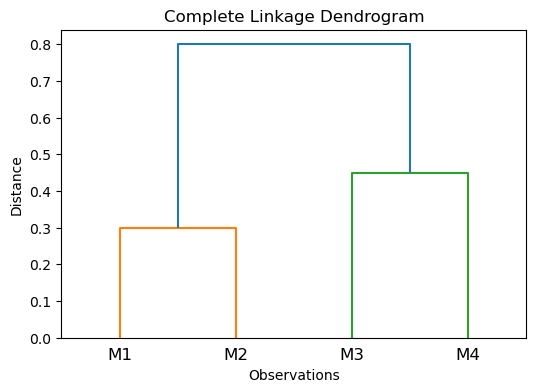

In [ ]:
# complete linkage
from scipy.spatial.distance import squareform

# Convert to condensed distance matrix (since linkage expects 1D form)
condensed = squareform(dissimilarity)

link_complete = linkage(condensed, method='complete')

plt.figure(figsize=(6,4))
dendrogram(link_complete, labels=['M1', 'M2', 'M3', 'M4'])
plt.title('Complete Linkage Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')
plt.show()

### Findouts:
- The shortest dissimilarity is between M1 and M2 (0.3), so they merge first.
- Then M3 merges at the maximum dissimilarity between clusters (complete linkage).
- Finally M4 joins at the highest linkage distance.

## (b) Single Linkage Dendrogram
 Repeat (a), this time using single linkage clustering.

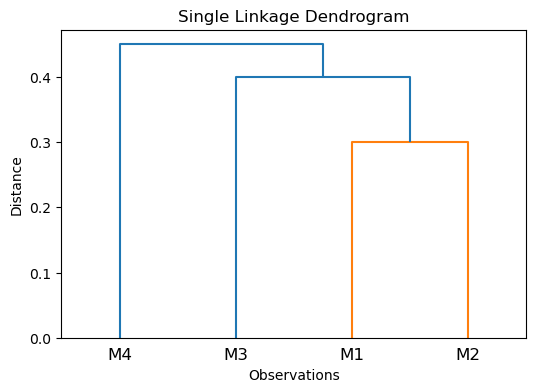

In [4]:
# Single linkage 
link_single = linkage(condensed, method='single')

plt.figure(figsize=(6,4))
dendrogram(link_single, labels=['M1', 'M2', 'M3', 'M4'])
plt.title('Single Linkage Dendrogram')
plt.xlabel('Observations')
plt.ylabel('Distance')
plt.show()

### Findouts:
This clustering structure suggests a gradual increase in dissimilarity : M1 ≈ M2 → M3 → M4

## (c) Clusters from Complete Linkage (Two Clusters)
uppose that we cut the dendrogram obtained in (a) such that two clusters result. Which observations are in each cluster?

In [5]:
# Cut dendrogram to get two clusters (complete linkage)
clusters_complete = fcluster(link_complete, t=2, criterion='maxclust')
cluster_df_complete = pd.DataFrame({'Observation': ['M1','M2','M3','M4'],
                                    'Cluster': clusters_complete})
cluster_df_complete

,Observation,Cluster
0,M1,1
1,M2,1
2,M3,2
3,M4,2


### Interpretation:
- The two clusters from complete linkage  are {M1, M2} and {M3, M4}.

## (d) Clusters from Single Linkage (Two Clusters)
Suppose that we cut the dendrogram obtained in (b) such that two clusters result. Which observations are in each cluster?

In [6]:
# Cut dendrogram to get two clusters (single linkage)
clusters_single = fcluster(link_single, t=2, criterion='maxclust')
cluster_df_single = pd.DataFrame({'Observation': ['M1','M2','M3','M4'],
                                  'Cluster': clusters_single})
cluster_df_single

,Observation,Cluster
0,M1,1
1,M2,1
2,M3,1
3,M4,2


### Interpretation:
- The two clusters from single linkage likely are {M1, M2, M3} and {M4}.

It is mentioned in this chapter that at each fusion in the dendrogram, the position of the two clusters being fused can be swapped without changing the meaning of the dendrogram. Draw a dendrogram that is equivalent to the dendrogram in (a), for which two or more of the leaves are repositioned, but for which the meaning of the dendrogram is the same.

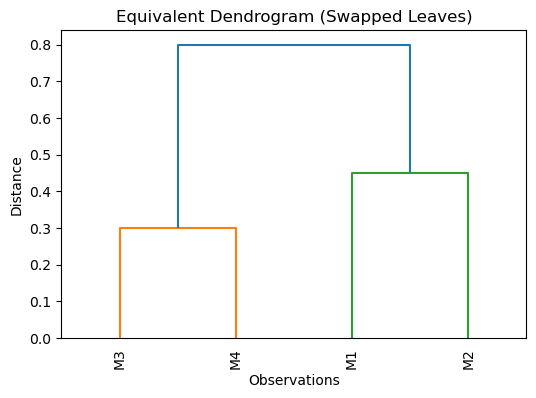

In [10]:
# Equivalent dendrogram (swapped leaf order)
plt.figure(figsize=(6, 4))
dendrogram(
    link_complete,
    labels=['M3', 'M4', 'M1', 'M2'],  # swapped/rearranged leaf order
    leaf_rotation=90,
    leaf_font_size=10
)
plt.title("Equivalent Dendrogram (Swapped Leaves)")
plt.xlabel("Observations")
plt.ylabel("Distance")
plt.show()



## Findouts:
In hierarchical clustering, swapping the left/right position of branches doesn’t change the meaning of the dendrogram.
Thus, the dendrogram from (a) can be mirrored without affecting interpretation.